## <font color="red"><u>Analisis Sentimen Ulasan pada E-Commerce Shopee di Google Playstore Menggunakan Naive Bayes Classifier (NBC)</u></font>

**By : Bayu Prasetyo (NIM : 22330008) Informatika-A Universitas Janabadra**

---

📌 **Dokumentasi Awal Proyek**

1. **Judul Proyek**  
   Analisis Sentimen Ulasan pada E-Commerce Shopee di Google Playstore Menggunakan Naive Bayes Classifier (NBC)

2. **Tujuan Penelitian**  
   - Mengumpulkan data ulasan aplikasi Shopee dari Google Playstore.
   - Melakukan tahap persiapan data (data preparation / data annotation) berupa pelabelan Data ulasan berdasarkan rating/bintang pengguna.  
   - Melakukan preprocessing teks ulasan yang meliputi case folding, cleansing, normalisasi, stopword removal, stemming, dan tokenizing.  
   - Mengklasifikasikan sentimen ulasan ke dalam kategori positif, netral, dan negatif menggunakan algoritma Naive Bayes Classifier.  
   - Mengevaluasi kinerja model klasifikasi menggunakan confusion matrix, akurasi, precision, recall, dan F1-score.

3. **Tahapan Penelitian**  
   1. Pengumpulan Data
  
      Pengambilan data ulasan aplikasi Shopee dari Google Play Store yang terdiri dari teks ulasan dan rating pengguna menggunakan library google play scrapper.

   2. Data Labelling (Pelabelan Data/Data Preparation/Data Annotation)

      Pelabelan sentimen dilakukan berdasarkan penilaian rating/bintang, yaitu Positif (Rating >= 4), Netral (Rating == 3), dan Negatif (Rating <= 2).

   3. Preprocessing Data Teks

      Proses pembersihan dan normalisasi teks ulasan yang meliputi:
      - Case folding
      - Cleansing
      - Normalisasi
      - Stopword removal
      - Stemming
      - Tokenizing

   4. Pembagian Data (Train–Test Split)

      Pembagian dataset menjadi data latih dan data uji untuk keperluan pelatihan dan evaluasi model.

   5. Ekstraksi Fitur (Feature Extraction)

      Transformasi teks hasil preprocessing ke dalam bentuk numerik menggunakan metode TF-IDF.

   6. Train Metode Naive Bayes Classifier (NBC) Dengan Model MultinomialNB

      Melatih metode NBC dengan model Multinomial Naive Bayes untuk memprediksi sentimen ulasan Shopee.

   7. Evaluasi Model

      Pengukuran performa model menggunakan confusion matrix serta metrik akurasi, precision, recall, dan F1-score.

   8. Visualisasi dan Interpretasi Hasil

      Penyajian dan analisis hasil klasifikasi sentimen untuk menarik kesimpulan penelitian.

---

**1. Pengumpulan Data**

Pengambilan data ulasan aplikasi Shopee dari Google Play Store yang terdiri dari teks ulasan dan rating pengguna menggunakan library google play scrapper.

**Tahap Scraping Data Google Playstore (Shopee Apps)**

In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00


**Import Library Yang Diperlukan (Pandas and Numpy)**

In [ ]:
from google_play_scraper import app
import pandas as pd
import numpy as np

**Scrape jumlah ulasan yang diinginkan**

In [ ]:
from google_play_scraper import Sort, reviews

result, continuation_token = reviews(
    'com.shopee.id',        # ID aplikasi Shopee di Google Playstore
    lang='id',              # Bahasa ulasan: Indonesia
    country='id',           # Lokasi Playstore: Indonesia
    sort=Sort.MOST_RELEVANT,# Urutkan ulasan paling relevan
    count=2000,             # Jumlah ulasan yang diambil (Misal: 2000)
    filter_score_with=None  # Ambil semua ulasan (rating 1 sampai 5)
)

**Tampilkan Hasil Data**



In [ ]:
import pandas as pd
from google.colab import files

# Upload file dari lokal
uploaded = files.upload()

# Ambil nama file yang diupload
filename = list(uploaded.keys())[0]

# Baca file CSV
df_shopee = pd.read_csv(filename)

# Tampilkan 2000 data pertama
df_shopee.head(2000)


Saving shopee_data.csv to shopee_data.csv


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,18a27faf-a7ac-41a2-8427-7d2cdace5531,laode onyo,https://play-lh.googleusercontent.com/a/ACg8oc...,Dulu bagus dan nyaman sekali belanja bebas pak...,2,21,3.60.30,2025-10-31 10:13:54,NaN,NaN,3.60.30
1,5512f617-7598-41f6-bb72-899f48599b06,Riko Ch,https://play-lh.googleusercontent.com/a-/ALV-U...,sampai sekarang aku masih nyaman pakai Shopee ...,5,402,3.60.30,2025-10-30 13:31:45,NaN,NaN,3.60.30
2,73924a77-66dc-4288-9fab-b5e124a13a4f,Rizki Pratama,https://play-lh.googleusercontent.com/a-/ALV-U...,Tolong buat fitur pilihan ya atau tidak dulu k...,1,13,3.60.30,2025-10-31 05:00:20,NaN,NaN,3.60.30
3,6beed3fc-e5a1-4cbc-ab7a-857a0969ca7c,sinaga daniel,https://play-lh.googleusercontent.com/a/ACg8oc...,"saya heran dngn shopee, kenapa J&T nya di hila...",1,62,3.60.30,2025-10-30 05:17:46,"Hi kak sinaga daniel, maaf ya sudah buat kmu g...",2025-10-30 06:32:59,3.60.30
4,5a5c877e-dfca-4cab-aded-2fa3e5997119,Iis Apih,https://play-lh.googleusercontent.com/a/ACg8oc...,"aku suka belanja di shopee,karna emang termura...",5,84,3.59.41,2025-10-31 01:13:25,NaN,NaN,3.59.41
...,...,...,...,...,...,...,...,...,...,...,...
1995,d594e201-b7aa-4b87-b065-e642793d6a82,Aris Fadarisman,https://play-lh.googleusercontent.com/a-/ALV-U...,Hari ini saya pesan barang pakai INSTAN tp sam...,1,2,3.57.31,2025-09-09 11:26:48,"Hai kak, maaf ya terkait pengembalian barang, ...",2022-12-30 23:20:31,3.57.31
1996,d94a1c28-eff9-4472-9e67-1f590633cbce,Sri Lestari,https://play-lh.googleusercontent.com/a-/ALV-U...,"kecewa banget akhirnya sama shopee,kenapa pemb...",5,10,3.56.29,2025-08-15 12:25:15,hai ka Sri Lestari mohon maaf atas pengiriman ...,2022-11-03 04:58:07,3.56.29
1997,1addede6-822c-4d75-80d4-c6e9c47d3fb5,Wily Yuliani,https://play-lh.googleusercontent.com/a-/ALV-U...,"sekarang proses pengembalian barang no ribet, ...",5,6,3.58.33,2025-09-21 22:49:27,"Hi Kak Wily Yuliani, makasih ya buat bintang 5...",2025-09-21 23:15:41,3.58.33
1998,71bd1c4b-df3c-4dd2-b874-be042b1bf7c9,Adit Dafi,https://play-lh.googleusercontent.com/a-/ALV-U...,"Kok lama2 malah tak bisa dibuka,, padahal udah...",5,2,3.58.33,2025-09-21 11:35:11,"Hai ka maaf yaa buat kendalanya, Mohon dapat m...",2022-12-25 02:34:00,3.58.33


**Hitung Kembali Jumlah Data Yang Didapat**

In [ ]:
len(df_shopee.index)

2000

**Filtering Kolom Data**

In [ ]:
# Menampilkan hanya kolom tertentu dari DataFrame df_shopee
# Kolom yang ditampilkan:
# - 'userName' → nama pengguna
# - 'score'    → rating/penilaian yang diberikan
# - 'at'       → tanggal/waktu ulasan
# - 'content'  → isi ulasan yang ditulis pengguna
df_shopee[['userName', 'score', 'at', 'content']]


,userName,score,at,content
0,laode onyo,2,2025-10-31 10:13:54,Dulu bagus dan nyaman sekali belanja bebas pak...
1,Riko Ch,5,2025-10-30 13:31:45,sampai sekarang aku masih nyaman pakai Shopee ...
2,Rizki Pratama,1,2025-10-31 05:00:20,Tolong buat fitur pilihan ya atau tidak dulu k...
3,sinaga daniel,1,2025-10-30 05:17:46,"saya heran dngn shopee, kenapa J&T nya di hila..."
4,Iis Apih,5,2025-10-31 01:13:25,"aku suka belanja di shopee,karna emang termura..."
...,...,...,...,...
1995,Aris Fadarisman,1,2025-09-09 11:26:48,Hari ini saya pesan barang pakai INSTAN tp sam...
1996,Sri Lestari,5,2025-08-15 12:25:15,"kecewa banget akhirnya sama shopee,kenapa pemb..."
1997,Wily Yuliani,5,2025-09-21 22:49:27,"sekarang proses pengembalian barang no ribet, ..."
1998,Adit Dafi,5,2025-09-21 11:35:11,"Kok lama2 malah tak bisa dibuka,, padahal udah..."


**Urutkan Data Berdasar Review Terbaru**

In [ ]:
# Ambil hanya kolom yang dibutuhkan dari DataFrame (username, skor, tanggal, dan isi ulasan)
new_df = df_shopee[['userName', 'score', 'at', 'content']]

# Urutkan data berdasarkan tanggal review terbaru ('at')
# ascending=False → artinya urut dari yang terbaru (newest) ke yang lama
# kalau mau urut dari yang lama ke baru, ubah jadi ascending=True
sorted_df = new_df.sort_values(by='at', ascending=False)

# Tampilkan 2000 data setelah diurutkan
sorted_df.head(2000)


,userName,score,at,content
1131,Manunggaling Jiwa,1,2025-11-01 02:28:02,syang tidak bisa melindungi konsumen saat penj...
56,Wibu gaming,4,2025-10-31 23:27:49,Jasa kirim POSINDO di shopee sangat buruk dan ...
1216,adi ongox,5,2025-10-31 17:41:49,selama ini lumayan sih dari pada toko sebelah....
46,"Mr, Razli",1,2025-10-31 17:34:13,"Ga kaya dulu,Apakah shopee udah beda sekarang,..."
242,Kevin Jeremy Simbolon,4,2025-10-31 17:33:54,Makin maju malah makin pelit dan bikin kesel g...
...,...,...,...,...
1614,2 They,2,2025-08-11 13:46:21,jasa kirim/kurir spx express bagus pertama nya...
1952,wulandharye,5,2025-08-11 13:25:09,SHOPEE INDONESIA sangat the best pokoknya bagu...
1695,wahyu rizky raharjo,1,2025-08-11 10:39:31,Kecewa dengan pihak shopee yg hanya berpihak d...
1680,Ms. Arlifah,2,2025-08-10 09:46:43,"awal buka pasti video, terus kalau dari keranj..."


**Simpan Hasil Sorting**

In [ ]:
# Menyimpan hasil sorting ke dalam variabel my_df dengan hanya kolom userName, score, at, dan content
my_df = sorted_df[['userName', 'score', 'at', 'content']]


**Filter Ulang (Menampilkan Content dan Rating)**

In [ ]:
# Karena kita hanya butuh kolom 'content' dan 'score', maka kita filter ulang
my_df = my_df[['content', 'score']]
# -> Menyisakan hanya kolom isi ulasan (content) dan rating (score)

In [ ]:
my_df.head(2000)

,content,score
1131,syang tidak bisa melindungi konsumen saat penj...,1
56,Jasa kirim POSINDO di shopee sangat buruk dan ...,4
1216,selama ini lumayan sih dari pada toko sebelah....,5
46,"Ga kaya dulu,Apakah shopee udah beda sekarang,...",1
242,Makin maju malah makin pelit dan bikin kesel g...,4
...,...,...
1614,jasa kirim/kurir spx express bagus pertama nya...,2
1952,SHOPEE INDONESIA sangat the best pokoknya bagu...,5
1695,Kecewa dengan pihak shopee yg hanya berpihak d...,1
1680,"awal buka pasti video, terus kalau dari keranj...",2


  **2. Data Labelling (Pelabelan Data/Data Preparation/Data Annotation)**

  Pelabelan sentimen dilakukan berdasarkan penilaian rating/bintang, yaitu Positif (Rating >= 4), Netral (Rating == 3),
  
  dan Negatif (Rating <= 2).

In [ ]:
# Fungsi untuk memberikan label sentimen berdasarkan skor rating
def pelabelan(score):
    if score <= 2:
        return 'Negatif'    # Skor 1-2 → ulasan negatif
    elif score == 3:
        return 'Netral'     # Skor 3 → ulasan netral
    elif score >= 4:
        return 'Positif'    # Skor 4-5 → ulasan positif

# Membuat kolom baru bernama 'Label' dengan hasil fungsi pelabelan
my_df['sentiment'] = my_df['score'].apply(pelabelan)

# Menampilkan 2000 data untuk memastikan label berhasil dibuat
my_df.head(2000)

,content,score,sentiment
1131,syang tidak bisa melindungi konsumen saat penj...,1,Negatif
56,Jasa kirim POSINDO di shopee sangat buruk dan ...,4,Positif
1216,selama ini lumayan sih dari pada toko sebelah....,5,Positif
46,"Ga kaya dulu,Apakah shopee udah beda sekarang,...",1,Negatif
242,Makin maju malah makin pelit dan bikin kesel g...,4,Positif
...,...,...,...
1614,jasa kirim/kurir spx express bagus pertama nya...,2,Negatif
1952,SHOPEE INDONESIA sangat the best pokoknya bagu...,5,Positif
1695,Kecewa dengan pihak shopee yg hanya berpihak d...,1,Negatif
1680,"awal buka pasti video, terus kalau dari keranj...",2,Negatif


**Simpan Hasil Labelling Data to CSV File**

In [ ]:
# Menyimpan dataset hasil scraping ke dalam file CSV
# index=False → agar indeks (0,1,2,...) tidak ikut tersimpan di file CSV
my_df.to_csv("labelling_data_shopee.csv", index=False)

**3. Preprocessing Data Teks**

Tahap pembersihan dan normalisasi teks (misalnya ulasan) agar lebih terstruktur dan siap diolah oleh metode text mining/NLP, seperti untuk analisis sentimen atau klasifikasi. Tahap ini membantu mengurangi “noise” dan membuat representasi teks lebih konsisten sehingga pemrosesan lanjutan lebih efektif.

Proses pembersihan dan normalisasi teks ulasan meliputi:

  - Case folding
  - Cleansing
  - Normalisasi
  - Stopword removal
  - Stemming
  - Tokenizing

**A. Case Folding**

Fungsi case folding adalah menyamaratakan bentuk huruf pada teks yang mana biasanya mengubah semua huruf menjadi huruf kecil (Lower Case) supaya penulisan yang beda kapital tidak dianggap kata yang berbeda. Dengan begitu, data jadi lebih konsisten dan mengurangi variasi yang tidak perlu (misalnya “Data”, “DATA”, dan “data” diperlakukan sama).

In [ ]:
import pandas as pd
import re

# 1. BACA FILE HASIL LABELLING
input_path = '/content/labelling_data_shopee.csv'
df = pd.read_csv(input_path)

# 2. PASTIKAN NAMA KOLOM
TEXT_COLUMN = 'content' # teks data review original

# 3. CASE FOLDING : Mengubah seluruh huruf menjadi lowercase tanpa menghapus simbol, angka, atau kata
def case_folding(text):
    if pd.isna(text):
        return ""
    return str(text).lower()

# Terapkan case folding
df['case_folding'] = df[TEXT_COLUMN].apply(case_folding)

# 4. SIMPAN DATASET LENGKAP
output_path = '/content/case_folding.csv'
df.to_csv(output_path, index=False)

print("File berhasil dibuat:", output_path)

# 5. PREVIEW HASIL
df.head(2000)


File berhasil dibuat: /content/case_folding.csv


,content,score,sentiment,case_folding
0,syang tidak bisa melindungi konsumen saat penj...,1,Negatif,syang tidak bisa melindungi konsumen saat penj...
1,Jasa kirim POSINDO di shopee sangat buruk dan ...,4,Positif,jasa kirim posindo di shopee sangat buruk dan ...
2,selama ini lumayan sih dari pada toko sebelah....,5,Positif,selama ini lumayan sih dari pada toko sebelah....
3,"Ga kaya dulu,Apakah shopee udah beda sekarang,...",1,Negatif,"ga kaya dulu,apakah shopee udah beda sekarang,..."
4,Makin maju malah makin pelit dan bikin kesel g...,4,Positif,makin maju malah makin pelit dan bikin kesel g...
...,...,...,...,...
1995,jasa kirim/kurir spx express bagus pertama nya...,2,Negatif,jasa kirim/kurir spx express bagus pertama nya...
1996,SHOPEE INDONESIA sangat the best pokoknya bagu...,5,Positif,shopee indonesia sangat the best pokoknya bagu...
1997,Kecewa dengan pihak shopee yg hanya berpihak d...,1,Negatif,kecewa dengan pihak shopee yg hanya berpihak d...
1998,"awal buka pasti video, terus kalau dari keranj...",2,Negatif,"awal buka pasti video, terus kalau dari keranj..."


**B. Data Cleansing Process**

Data cleansing process merupakan tahap pembersihan data teks dari berbagai elemen yang tidak relevan atau mengganggu proses analisis, seperti karakter khusus, tanda baca, angka, URL, emoji, serta spasi berlebih. Tahap ini bertujuan untuk menghasilkan data yang lebih bersih, konsisten, dan siap digunakan pada proses analisis sentimen sehingga dapat meningkatkan kualitas serta akurasi model yang dibangun.

In [ ]:
import pandas as pd
import re

# BACA FILE CASE FOLDING
df = pd.read_csv('/content/case_folding.csv')

# CLEANSING
def cleansing(text):
    if pd.isna(text):
        return ""

# Menghapus URL atau tautan website
    text = re.sub(r'http\S+|www\S+', ' ', text)

# Menghapus seluruh angka (0–9)
    text = re.sub(r'\d+', ' ', text)

# Menghapus tanda baca, simbol, dan karakter selain huruf alfabet
# Hanya mempertahankan huruf a–z dan spasi
    text = re.sub(r'[^a-z\s]', ' ', text)

# Menghapus spasi berlebih (lebih dari satu spasi)
# Serta menghapus spasi di awal dan akhir kalimat
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['cleansing'] = df['case_folding'].apply(cleansing)

# SIMPAN FILE CLEANSING
df.to_csv('/content/cleansing.csv', index=False)

print("cleansing.csv berhasil dibuat")
df.head(2000)


cleansing.csv berhasil dibuat


,content,score,sentiment,case_folding,cleansing
0,syang tidak bisa melindungi konsumen saat penj...,1,Negatif,syang tidak bisa melindungi konsumen saat penj...,syang tidak bisa melindungi konsumen saat penj...
1,Jasa kirim POSINDO di shopee sangat buruk dan ...,4,Positif,jasa kirim posindo di shopee sangat buruk dan ...,jasa kirim posindo di shopee sangat buruk dan ...
2,selama ini lumayan sih dari pada toko sebelah....,5,Positif,selama ini lumayan sih dari pada toko sebelah....,selama ini lumayan sih dari pada toko sebelah ...
3,"Ga kaya dulu,Apakah shopee udah beda sekarang,...",1,Negatif,"ga kaya dulu,apakah shopee udah beda sekarang,...",ga kaya dulu apakah shopee udah beda sekarang ...
4,Makin maju malah makin pelit dan bikin kesel g...,4,Positif,makin maju malah makin pelit dan bikin kesel g...,makin maju malah makin pelit dan bikin kesel g...
...,...,...,...,...,...
1995,jasa kirim/kurir spx express bagus pertama nya...,2,Negatif,jasa kirim/kurir spx express bagus pertama nya...,jasa kirim kurir spx express bagus pertama nya...
1996,SHOPEE INDONESIA sangat the best pokoknya bagu...,5,Positif,shopee indonesia sangat the best pokoknya bagu...,shopee indonesia sangat the best pokoknya bagu...
1997,Kecewa dengan pihak shopee yg hanya berpihak d...,1,Negatif,kecewa dengan pihak shopee yg hanya berpihak d...,kecewa dengan pihak shopee yg hanya berpihak d...
1998,"awal buka pasti video, terus kalau dari keranj...",2,Negatif,"awal buka pasti video, terus kalau dari keranj...",awal buka pasti video terus kalau dari keranja...


**C. Normalisasi Process**

Normalisasi merupakan proses mengubah kata-kata tidak baku, singkatan, atau variasi penulisan dalam teks ulasan menjadi bentuk kata baku sesuai dengan kaidah bahasa. Proses ini bertujuan untuk menyamakan representasi kata sehingga mengurangi keragaman kata yang memiliki makna sama, serta membantu meningkatkan kualitas fitur teks dan kinerja model analisis sentimen.

In [ ]:
import pandas as pd
import re

# 1. LOAD DATA CLEANSING
df = pd.read_csv("cleansing.csv")

# pastikan kolom cleansing ada
if "cleansing" not in df.columns:
    raise ValueError("Kolom 'cleansing' tidak ditemukan")

# 2. KAMUS NORMALISASI MANUAL
normalization_dict = {
    # Singkatan dan kata informal
    'syang': 'sayang', 'ato': 'atau', 'yg': 'yang', 'dangan': 'dengan', 'diretur': 'dikembalikan',
    'apk': 'aplikasi', 'pake': 'pakai', 'dari pada': 'daripada', 'oke': 'baik', 'gua': 'saya',
    'gak': 'tidak', 'cod': 'cash on delivery', 'tolong lah': 'tolonglah', 'harii': 'hari',
    'ga': 'tidak', 'kaya': 'seperti', 'udah': 'sudah', 'banget': 'sekali', 'trimakasih': 'terimakasih',
    'mandeg': 'berhenti', 'kesel': 'kesal', 'gada': 'tidak ada', 'bener': 'benar',
    'bgt': 'sekali', 'tau': 'tahu', 'gtu': 'begitu', 'gausah': 'tidak perlu', 'emng': 'memang',
    'sama aja': 'sama saja', 'makin': 'semakin', 'sy': 'saya', 'wa': 'whatsapp', 'doangg': 'saja',
    'kesini': 'ke sini', 'pengguna nya': 'penggunanya', 'kya': 'kaya', 'th': 'itu', 'mbulet': 'ribet',
    'rb': 'ribu', 'keatas': 'ke atas', 'dapet': 'dapat', 'tgl': 'tanggal', 'chatt': 'chat',
    'aku': 'saya', 'byr cod': 'bayar cash on delivery', 'gunain': 'gunakan', 'makana': 'makan',
    'hp': 'handphone', 'diacc': 'diterima', 'capek': 'lelah', 'nyesal': 'sesal', 'spx': 'shopee express',
    'beginii': 'seperti ini', 'iy': 'iya', 'pcs': 'pieces', 'spx express': 'shopee express',
    'yth': 'yang terhormat', 'kalsel': 'kalimantan selatan', 'min': 'admin', 'ngambil': 'mengambil',
    'sopee': 'shopee', 'vocer': 'voucher', 'mkjn': 'semakin', 'usah': 'perlu', 'gk': 'tidak',
    'seblumnya': 'sebelumnya', 'dipake': 'dipakai', 'byr': 'bayar', 'jngn': 'jangan',
    'jt': 'juta', 'dkit': 'sedikit', 'y': 'ya', 'ngelek': 'ngelag', 'hri': 'hari',
    'brg': 'barang', 'cape': 'lelah', 'kmi': 'kami', 'dtggu': 'ditunggu', 'ms': 'masih',
    'dsini': 'disini', 'ngasih': 'memberi', 'sdngkan': 'sedangkan', 'blg': 'bilang', 'slh': 'salah',
    'tidam': 'tidak', 'pad': 'pada', 'gtw': 'tidak tahu', 'dlu': 'dulu', 'ny': 'nya',
    'otp': 'one time password', 'jgan': 'jangan', 'namnya': 'namanya', 'okt': 'oktober',
    'almt': 'alamat', 'ktanya': 'katanya', 'jlas': 'jelas', 'trima': 'terima', 'klau': 'kalau',
    'tlp': 'telepone', 'tnpa': 'tanpa', 'dm': 'direct message', 'ter nyata': 'ternyata',
    'skrg': 'sekarang', 'ku': 'aku', 'ngalamin': 'mengalami', 'masi': 'masih', 'malat': 'malah',
    'ngga': 'tidak', 'tu': 'itu', 'ngelag': 'lambat jaringan', 'apknya': 'aplikasinya',
    'delay': 'terjeda', 'gabisa': 'tidak bisa', 'gitu': 'begitu', 'daruratt': 'darurat',
    'kalo': 'kalau', 'jdi': 'jadi', 'tk': 'saya', 'dll': 'dan lain lain', 'dlm': 'dalam',
    'ky': 'seperti', 'ak': 'aku', 'pd': 'pada', 'krn': 'karena', 'nggak': 'tidak', 'tuh': 'itu',
    'thanks you': 'terimakasih', 'kayak': 'seperti', 'angkir': 'biaya kirim', 'cek out': 'checkout',
    'pas': 'ketika', 'anehh': 'aneh', 'bangett': 'banget', 'emang': 'memang', 'psanan': 'pesanan',
    'adain': 'adakan', 'apl': 'aplikasi', 'wktnya': 'waktunya', 'ad': 'ada', 'jdinya': 'jadinya',
    'dimn': 'dimana', 'bs': 'bisa', 'mjd': 'menjadi', 'motifasi': 'motivasi', 'ahh': 'lah',
    'sbh': 'sebuah', 'utk': 'untuk', 'nyenggol': 'menyenggol', 'scr': 'secara', 'baramg': 'barang',
    'lgsg': 'langsung', 'sih': 'juga', 'krg': 'kurang', 'pny': 'punya', 'komplein': 'kompalin',
    'gw': 'saya', 'ngespam': 'spam', 'kgk': 'tidak', 'b aja doang': 'biasa saja', 'lambatt': 'lambat',
    'bop': 'bodoh', 'pencet': 'tekan', 'lu': 'kamu', 'aj': 'saja', 'x': 'kali', 'stelan': 'setelan',
    'dpt': 'dapat', 'knapa': 'kenapa', 'amat': 'banget', 'sdh': 'sudah', 'udh': 'sudah',
    'for all': 'untuk semua', 'murmer': 'murah meriah', 'ngk': 'tidak', 'gimix': 'strategi',
    'lgi': 'lagi', 'kaga': 'tidak', 'acc': 'terima', 'kepembeli': 'ke pembeli', 'warning': 'perhatikan',
    'dgudang': 'digudang', 'sorti': 'sortir', 'kirain': 'perkiraan', 'cuman': 'cuma',
    'e': 'malah', 'selelet': 'selambat', 'tgal': 'tanggal', 'yahh': 'ya', 'pdhal': 'padahal',
    'd tetappkan': 'di tetapkan', 'bug': 'masalah teknis', 'lag': 'jeda waktu', 'jwb': 'jawab',
    'spinjam': 'shopee pinjam', 'donk': '', 'lawak': 'lucu', 'cumah': 'tetapi', 'custamer': 'customer',
    'spx expres': 'shopee express', 'nge': '', 'tolong donk': 'tolonglah', 'ongkir': 'biaya kirim',
    'coinnya': 'koinnya', 'recenya': 'recehnya', 'pleasee': 'saya mohon', 'unintall': 'uninstall',
    'trimksh': 'terima kasih', 'lbh': 'lebih', 'pernah k kalau': 'pernah kalau', 'pdahal': 'padahal',
    'sgt': 'sangat', 'thd': 'terhadap', 'sihh': 'sih', 'juaraa': 'juara', 'engk': 'tidak',
    'plus': 'lebih', 'app': 'aplikasi', 'ngecek': 'mengecek', 'jga': 'juga', 'rubah': 'ubah',
    'sosmed': 'sosial media', 'm': '', 'keknya': 'sepertinya', 'ori': 'asli', 'kadih': 'kasih',
    'co': 'checkout', 'telo': 'sialan', 'ngawur': 'sembarangan', 'trimakasi': 'terimakasih',
    'culas': 'curang', 'mulu': 'terus', 'gini': 'seperti ini', 'deh': 'jadinya', 'sekqrang': 'sekarang',
    'gabsa': 'tidak bisa', 'tlg dong': 'tolonglah', 'msh': 'masih', 'diisaku': 'disaku',
    'jaksel': 'jakarta selatan', 'ribet': 'sulit', 'g': 'tidak', 'unoxing': 'unboxing',
    'posindo': 'pos indonesia', 'shoope': 'shopee', 'bikin': 'membuat', 'vocher': 'voucher',
    'sebener nya': 'sebenarnya', 'ngebantu': 'membantu', 'vidio': 'video', 'reting': 'rating',
    'sekali gus': 'sekaligus', 'hrs': 'harus', 'nyari': 'mencari', 'menembalikan': 'mengembalikan',
    'sampe': 'sampai', 'penelgembalian': 'pengembalian', 'ol': 'online', 'se enaknya': 'seenaknya',
    'gampang': 'mudah', 'mslh': 'masalah', 'pengirima': 'pengiriman', 'aga': 'agak',
    'kek': 'seperti', 'ni': 'ini', 'gercep': 'gerak cepat', 'tp': 'tapi', 'sophee': 'shopee',
    'ngumpulin': 'mengumpulkan', 'capek deh': 'lelah', 'tempanya': 'tempatnya', 'php': 'pemberi harapan palsu',
    'bgtt': 'banget', 'baguss': 'bagus', 'tetep': 'tetap', 'anter': 'antar', 'sjarang': 'jarang',
    'jd': 'jadi', 'jadii': 'jadi', 'lelet': 'lambat', 'lamaa': 'lama', 'kebabasan': 'kebebasan',
    'sz': 'size', 'dl': 'dulu', 'ok': 'baik', 'retur': 'kembalikan', 'perpnjang': 'perpanjang',
    'apes': 'sial', 'fraud': 'penipuan', 'returnya': 'pengembaliannya', 'komplet': 'lengkap',
    'biar': 'supaya', 'rame': 'ramai', 'kadi': 'jadi', 'shope': 'shopee', 'castemernya': 'customernya',
    'uda': 'sudah', 'batalin': 'batalkan', 'lemot': 'lambat', 'skrng': 'sekarang',
    'nyampai': 'sampai', 'kok': 'malah', 'ribet': 'sulit', 'yah': 'ya', 'mencewakan': 'mengecewakan',
    'eh': 'malah', 'ah': 'malah', 'so lame': 'sangat lama', 'trus': 'terus', 'klo': 'kalau',
    'lahaula walakuata illabillah': 'la hawla wala quwwata illa billah', 'smg': 'semoga',
    'sma': 'sama', 'coin': 'koin', 'rece': 'receh', 'mjd': 'menjadi',  'bnget': 'sekali',
    'dg': 'dengan', 'nggk': 'tidak', 'sllu': 'selalu', 'gamabar': 'gambar', 'dpat': 'dapat', 'dn': 'dan',
    'skrg': 'sekarang', 'bsa': 'bisa', 'jg': 'juga', 'dgn': 'dengan', 'bgtu': 'begitu',
    'aja': 'saja', 'napa': 'kenapa', 'dah': 'sudah', 'tidak karuan': 'berantakan', 'ngirim': 'kirim',
    'doang': 'saja', 'yng': 'yang', 'deh': 'jadinya', 'bsa': 'bisa', 'jg': 'juga',
    'dr': 'dari', 'tdk': 'tidak', 'baju b': 'baju biasa', 'gimna': 'gimana', 'sekali gus': 'sekaligus',
    'mnt': 'menit', 'overall': 'semuanya', 'karuan': 'tertata', 'ampe': 'sampai', 'trmksh': 'terimakasih',
    'full': 'penuh', 'applikasinya': 'aplikasinya', 'shoppe': 'shopee', 'lt': 'liter', 'basii': 'basi',
    'dst': 'dan seterusnya', 'pedang': 'pedagang', 'kg': 'kilogram', 'gr': 'gram', 'makjn': 'makin',
    'roundap': 'roundup', 'kodog': 'kodok', 'cm': 'centimeter', 'life': 'live', 'chek uot': 'checkout',
    'cs': 'customer service', 'chek out': 'checkout', 'balik': 'kembali', 'yaa': 'ya',
    'ogah': 'tidak mau', 'ngerti': 'mengerti', 'kyak': 'seperti', 'org': 'orang', 'tbtb': 'tiba tiba',
    'kalap': 'hilang kendali', 'dtg': 'datang', 'ttp': 'tetap', 'tolong dong': 'tolonglah',
    'muak': 'benci', 'koq': 'malah', 'moment': 'momen', 'mah': 'malah', 'duh': 'aduh',
    'kmarin': 'kemarin', 'ngerasain': 'merasakan', 'sndiri': 'sendiri', 'gara': 'akibat',
    'knp': 'kenapa', 'dng': 'dengan', 'spek': 'kualitas', 'kasi': 'memberikan', 'bgs': 'bagus',
    'mkn': 'mungkin', 'd': 'di', 'vocernya': 'vouchernya', 'kl': 'kalau', 'seler': 'seller', 'blm': 'belum',
    'jgn': 'jangan', 'trnyta': 'ternyata', 'yak': 'ya', 'hrga': 'harga', 'kwalitas': 'kualitas',
    'bnyk': 'banyak', 'cm': 'cuma', 'unt': 'untuk', 'masyrakt': 'masyarakat', 'warpnya': 'wrapnya',
    'kepoan': 'ingin tahu', 'ngecancel': 'mengcancel', 'po': 'pre order', 'untu': 'untuk',
    'hang': 'masalah teknis', 'hrus': 'harus', 'trs': 'terus', 'hari h': 'hari pelaksanaannya',
    'tempa': 'tempat', 'spx epress': 'shopee express', 'bego': 'bodoh', 'the best': 'terbaik',
    'chus': 'ayo', 'sebenerx': 'sebenarnya', 'expedisi': 'ekspedisi', 'jne': 'jalur nugraha eka kurir',
    'pst': 'pasti', 'sm': 'sama', 'dengerin': 'dengarkan', 'sndr': 'sendiri', 'is ok': 'baik',
    'byk': 'banyak', 'dperhatikan': 'diperhatikan', 'ja': 'saja', 'gubris': 'layani', 'wiifi': 'wifi',
    'lg': 'lagi', 'klu': 'kalau', 'perabot': 'parabot', 'sampeknya': 'sampainya', 'tpi': 'tapi',
    'jabodetabek': 'jakarta bogor depok tangerang bekasi', 'pesen': 'pesan', 'dateng': 'datang',
    'kepake': 'terpakai', 'gara gara': 'akibat', 'batnag': 'barang', 'no': 'nomor', 'telpon': 'telepon',
    'klu': 'kalau', 'moga': 'semoga', 'ilangin': 'hilangkan', 'diskonya': 'discountnya',
    'tks': 'terimakasih', 'kw': 'palsu', 'da': 'ada', 'cepet': 'cepat', 'smpe': 'sampai', 'hub': 'gudang',
    'dc': 'distribution center', 'laen': 'lain', 'gmn': 'bagaimana', 'no problem': 'tidak masalah',
    'ruamah': 'rumah', 'ynag': 'yang', 'gendala': 'kendala', 'mengatad': 'mengatas', 'consumen': 'konsumen',
    'dikit': 'sedikit', 'males': 'malas', 'bjir': 'sial', 'ai': 'artificial intellegent',
    'stiap': 'setiap', 'kmrn': 'kemarin', 'antaraja': 'anteraja', 'batalkn': 'batalkan', 'krna': 'karena',
    'sj': 'saja', 'nyampe': 'sampai', 'br': 'baru', 'matiar': 'matrial', 'pensen': 'persen',
    'aq': 'aku', 'nyampek': 'sampai', 'nongol': 'terlihat', 'nyuruh': 'memerintah', 'gb': 'gigabyte',
    'dri': 'dari', 'copayment': 'checkout payment', 'dirmh': 'dirumah', 'mengobrak abrik': 'mengacak acak',
    'mgga': 'tidak', 'drmh': 'dirumah', 'dear': 'untuk', 'bok': 'box', 'uinstall': 'uninstall',
    'nyesel': 'menyesal', 'dsni': 'disini', 'tambahanin': 'tambahkan', 'ekpedisi': 'ekspedisi',
    'kepastianny': 'kepastiannya', 'orng': 'orang', 'teruss': 'terus', 'jkt': 'jakarta', 'hr': 'hari',
    'mesan': 'pesan', 'tik tok': 'tiktok', 'qr': 'quick response', 'vip': 'very important person',
    'gitusiihh': 'begitu', 'njemput': 'jemput', 'sbnar': 'sebenarnya', 'snagat': 'sangat',
    'ksih': 'kasih', 'bgi': 'bagi', 'mrka': 'mereka', 'btul': 'betul', 'brpa': 'berapa', 'sampek': 'sampai',
    'byar': 'bayar', 'bnar': 'benar', 'pokonya': 'pokoknya', 'komplen': 'komplain', 'kdang': 'kadang',
    'garagara': 'akibat', 'std': 'standar', 'eco': 'ekonomi', 'ksh': 'kasih',  'phonsel': 'ponsel',
    'medsos': 'media sosial', 'sngat': 'sangat', 'skli': 'sekali', 'hnya': 'hanya', 'tnggal': 'tanggal',
    'rada': 'agak', 'doble': 'double', 'tlong': 'tolong', 'cerewett': 'cerewet', 'tlpn': 'telepon',
    'appnya': 'aplikasinya', 'jugak': 'juga', 'enggak': 'tidak', 'tinggkan': 'tingkatkan'
  }

# 3. FUNGSI NORMALISASI
def normalize_text(text):
    if pd.isna(text):
        return ""

    # normalisasi huruf berulang (misal : bagusss -> bagus)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # normalisasi frasa dulu
    for key, val in sorted(normalization_dict.items(), key=lambda x: len(x[0]), reverse=True):
        pattern = r'\b' + re.escape(key) + r'\b'
        text = re.sub(pattern, val, text)

    return text

# 4. TERAPKAN NORMALISASI
df["normalisasi"] = df["cleansing"].apply(normalize_text)

# 5. SIMPAN KE CSV
df.to_csv("normalisasi.csv", index=False)

print("✅ Normalisasi selesai. File disimpan sebagai normalisasi.csv")

df.head(2000)


✅ Normalisasi selesai. File disimpan sebagai normalisasi.csv


,content,score,sentiment,case_folding,cleansing,normalisasi
0,syang tidak bisa melindungi konsumen saat penj...,1,Negatif,syang tidak bisa melindungi konsumen saat penj...,syang tidak bisa melindungi konsumen saat penj...,sayang tidak bisa melindungi konsumen saat pen...
1,Jasa kirim POSINDO di shopee sangat buruk dan ...,4,Positif,jasa kirim posindo di shopee sangat buruk dan ...,jasa kirim posindo di shopee sangat buruk dan ...,jasa kirim pos indonesia di shopee sangat buru...
2,selama ini lumayan sih dari pada toko sebelah....,5,Positif,selama ini lumayan sih dari pada toko sebelah....,selama ini lumayan sih dari pada toko sebelah ...,selama ini lumayan juga daripada toko sebelah ...
3,"Ga kaya dulu,Apakah shopee udah beda sekarang,...",1,Negatif,"ga kaya dulu,apakah shopee udah beda sekarang,...",ga kaya dulu apakah shopee udah beda sekarang ...,tidak seperti dulu apakah shopee sudah beda se...
4,Makin maju malah makin pelit dan bikin kesel g...,4,Positif,makin maju malah makin pelit dan bikin kesel g...,makin maju malah makin pelit dan bikin kesel g...,semakin maju malah semakin pelit dan membuat k...
...,...,...,...,...,...,...
1995,jasa kirim/kurir spx express bagus pertama nya...,2,Negatif,jasa kirim/kurir spx express bagus pertama nya...,jasa kirim kurir spx express bagus pertama nya...,jasa kirim kurir shopee express bagus pertama ...
1996,SHOPEE INDONESIA sangat the best pokoknya bagu...,5,Positif,shopee indonesia sangat the best pokoknya bagu...,shopee indonesia sangat the best pokoknya bagu...,shopee indonesia sangat terbaik pokoknya bagus...
1997,Kecewa dengan pihak shopee yg hanya berpihak d...,1,Negatif,kecewa dengan pihak shopee yg hanya berpihak d...,kecewa dengan pihak shopee yg hanya berpihak d...,kecewa dengan pihak shopee yang hanya berpihak...
1998,"awal buka pasti video, terus kalau dari keranj...",2,Negatif,"awal buka pasti video, terus kalau dari keranj...",awal buka pasti video terus kalau dari keranja...,awal buka pasti video terus kalau dari keranja...


**D. Stopword Removal Process**

Stopword removal merupakan proses penghapusan kata-kata umum yang sering muncul namun tidak memiliki kontribusi signifikan terhadap penentuan sentimen, seperti kata hubung, kata ganti, dan kata keterangan. Tujuan dari proses ini adalah untuk mengurangi noise pada data teks, memperkecil dimensi fitur, serta memfokuskan analisis pada kata-kata yang lebih bermakna sehingga dapat meningkatkan efektivitas dan akurasi model analisis sentimen.

In [ ]:
import pandas as pd

# ===============================
# 1. LOAD FILE NORMALISASI
# ===============================
df = pd.read_csv("normalisasi.csv")

# pastikan kolom normalisasi ada
if "normalisasi" not in df.columns:
    raise ValueError("Kolom 'normalisasi' tidak ditemukan di normalisasi.csv")

# ===============================
# 2. STOPWORD MANUAL
# ===============================
manual_stopwords = set([
    'saya','aku','kamu','dia','mereka','kami','kita','orang','keadaan','yang',
    'pembeli','penjual','seller','user','pengguna', 'begitu','seperti','begini',
    'hal','cara','kondisi', 'menit', 'baru','sebelumnya', 'chat', 'begitu',
    'dan','atau','dengan','tanpa','oleh','untuk','dari','ke','di','pada','dalam',
    'agar','supaya','karena','hingga','meskipun','walaupun', 'detik',
    'sehingga','bahwa','kalau','jika','bila', 'hari','tanggal','bulan','tahun',
    'kemarin','sekarang','besok','tadi','nanti','pernah', 'ini','itu','tersebut',
    'sudah','belum','sedang','masih','lagi','akan','telah', 'selalu', 'jam',
    'sekali','banget', 'amat','paling', 'whatsapp', 'wilayah', 'ubah', 'ujian',
    'terlalu', 'ada','tidak','bisa','harus','ingin','mau','perlu','boleh',
    'jadi','menjadi','tetap','langsung','memang','ternyata', 'fitur','sistem',
    'ya','yah','lah','loh','kok','mah','deh','dong','versi','cuma','hanya',
    'eh','ah','aduh','duh','hehe','haha','wkwk', 'pembayaran','on',
    'tolong','mohon', 'login','logout', 'makan', 'ternyata', 'jadinya', 'lah',
    'silakan','harap','thanks', 'saja', 'kwkwk', 'checkout','payment','bayar',
    'shopee','aplikasi','akun','pieces','unit','kali','box','paket', 'gudang',
    'cash','delivery','voucher','diskon','promo', 'koin','saldo', 'pos', 'anteraja',
    'refund','transaksi','order','pesanan', 'indonesia', 'ekspedisi','kurir',
    'pengiriman', 'shopee', 'distribution','center', 'admin', 'datangnya',
    'customer','service','helpdesk','layanan','centimeter','gigabyte','persen',
    'jumlah', 'kilogram', 'cuma','liter', 'jakarta','jakarta selatan','bogor',
    'tangerang', 'bekasi', 'alamat','rumah','kota','daerah', 'jalur nugraha eka kurir',
    'internet','jaringan', 'yang', 'yuk', 'tuh', 'nomor','telepon','wifi',
    'lain','lainnya','semua','total', 'online','offline', 'expedisi', 'depok',
    'overall','full','isi', 'bro', 'bisa', 'bagian','proses', 'signal',
    'ada', 'adakan', 'adalah', 'adanya', 'admin', 'agar', 'saja', 'ajukan',
    'akhir', 'aktivitas', 'aku', 'akun', 'alasan', 'akhirnya', 'aplikasi',
    'ambil', 'anak', 'anda', 'antar', 'si', 'apa', 'apalagi', 'apapun',
    'aplikasinya', 'atas', 'atau', 'awal', 'awalnya', 'bagaimana', 'bagi',
    'bahkan', 'bahwa', 'bakal', 'balas', 'bank', 'padahal', 'barang',
    'benar', 'beranda', 'berbeda', 'beri', 'berita', 'berkali', 'media sosial',
    'berlaku', 'bertanya', 'berubah', 'barang', 'biaya', 'saja', 'customer',
    'betul', 'biasa', 'biasanya', 'biar', 'biaya', 'bikin', 'bilang', 'bintang',
    'bisanya', 'bukan', 'boleh', 'bolak', 'habis', 'bot', 'akan', 'sekarang',
    'barangnya', 'batas', 'bayar', 'beberapa', 'belanja', 'beli', 'tokopedia',
    'buat', 'buka', 'bukti', 'cair', 'bulan', 'bunda', 'buyer', 'cache',
    'cari', 'cash', 'cek', 'chat', 'checkout', 'coba','akal', 'dahulu',
    'contoh', 'cukup', 'cuma', 'cust', 'customer', 'daerah', 'daftar',
    'dalam', 'dan', 'dana', 'dapat', 'dari', 'daripada', 'data', 'datang',
    'deh', 'dekat', 'dengan', 'depan', 'deskripsi', 'detik', 'dikirim',
    'di', 'dia', 'diantar', 'dibayar', 'diberi', 'dibuat', 'didalam',
    'diganti', 'digunakan', 'dihapus', 'dijual', 'dikemas', 'dikembalikan',
    'dimana', 'diminta', 'dipakai', 'diproses', 'dirumah', 'disana', 'ulang',
    'disini', 'disitu', 'disuruh', 'ditambah', 'diterima', 'ditunggu',
    'saja', 'dompet', 'dong', 'download', 'driver', 'ulasan', 'jadwal',
    'dulu', 'duit', 'efek', 'ekspedisi', 'email', 'memang', 'estimasi',
    'fitur', 'foto', 'free', 'saya', 'fungsi', 'game', 'gimana', 'gini',
    'golongan', 'google', 'gopay', 'gosend', 'grab', 'guna', 'gunakan',
    'halaman', 'hampir', 'hanya', 'hapus', 'harga', 'hari', 'harus',
    'hati', 'hilang', 'history', 'home', 'hubungi', 'id', 'iklan',
    'ikut', 'ilang', 'info', 'informasi', 'ingin', 'ini', 'input',
    'internet', 'isi', 'istri', 'item', 'itu', 'iya', 'jadi', 'jadinya',
    'jaga', 'jalan', 'jam', 'jangan', 'jarak', 'jarang', 'jasa', 'jauh',
    'jawab', 'jawaban', 'jenis', 'jika', 'jualan', 'juga', 'install',
    'justru', 'juta', 'kabupaten', 'kak', 'kali', 'kalian', 'kalo', 'kami',
    'kamis', 'kampung', 'kamu', 'kan', 'kapan', 'karena', 'karna', 'kartu',
    'kata', 'katanya', 'ke', 'keadaan', 'kebutuhan', 'kecuali', 'semoga',
    'kedepan', 'kedepannya', 'kejadian', 'keluar', 'kemana', 'sipaling',
    'kemarin', 'kembali', 'kembalikan', 'kemudian', 'kena', 'kenapa',
    'kepada', 'kepencet', 'keputusan', 'keranjang', 'kerja', 'keterangan',
    'koin', 'kok', 'komen', 'nya', 'komentar', 'komunikasi', 'kondisi',
    'konfirmasi', 'konsumen', 'hasil', 'kontak', 'kredit', 'kuota',
    'kurir', 'kurirnya', 'lagi', 'lah', 'lain', 'lainnya', 'lalu',
    'langsung', 'lanjut', 'lapor', 'laporan', 'layanan', 'layar', 'lazada',
    'lewat', 'lihat', 'link', 'live', 'loading', 'mengirim', 'kasih',
    'login', 'loh', 'lokasi', 'lol', 'luar', 'lupa', 'maaf', 'macam',
    'main', 'maka', 'makan', 'makananan', 'maka', 'malah', 'hanya', 'tanggal',
    'malam', 'mana', 'manusia', 'mas', 'masa', 'masih', 'double', 'membeli',
    'masing', 'masuk', 'masukan', 'mata', 'mau', 'maupun', 'mbanking',
    'melalui', 'melihat', 'memakai', 'memang', 'memastikan', 'membayar',
    'memberi', 'memberikan', 'membuat', 'memesan', 'memilih', 'meminta', 'mencari',
    'mencoba', 'mendapat', 'mendapatkan', 'mending', 'menerima', 'mengajukan',
    'mengalami', 'mengambil', 'mengerti', 'menggunakan', 'menghubungi',
    'mengisi', 'mengulang', 'menit', 'menjual', 'menu', 'memang', 'pesanan',
    'menurut', 'mereka', 'bisa', 'bagiku', 'tokonya', 'makin', 'kasih', 'saya',
    'meski', 'meskipun', 'shopi', 'tertera', 'berbagai', 'tahun', 'edit',
    'misalnya', 'mitra', 'mobil', 'mode', 'model', 'mohon', 'motor', 'jual', 'antar',
    'ingin', 'nonton', 'beku', 'kira', 'kerja', 'tampil', 'lebih', 'suara',
    'atur', 'uang', 'ongkirnya', 'soal', 'bagai', 'selalu', 'on', 'ongkir',
    'shopeefood', 'pihak', 'shop', 'melakukan',  'paling', 'pakai', 'pasar', 'pay',
    'nomer', 'important', 'person', 'kirim', 'jangkau', 'muas', 'obat', 'ojol',
    'mungkin', 'muncul', 'nama', 'namanya', 'namun', 'nanti', 'via', 'ojek',
    'nilai', 'nomor', 'non', 'nongol', 'notif', 'notifikasi', 'nunggu',
    'ongkos', 'online', 'opsi', 'orang', 'order', 'orderan', 'makanan',
    'pada', 'padahal', 'pagi', 'pajak', 'pak', 'pakai', 'paket', 'paketan',
    'paylater', 'pelanggan', 'pelapak', 'pelayanan', 'unduh', 'untuk',
    'pembayar', 'pembayaran', 'pembeli', 'pembelian', 'pemberitahuan', 'pemula',
    'penanganan', 'pencarian', 'ya', 'pendapatan', 'penerima', 'gerak',
    'pengaturan', 'pengemasan', 'pengembalian', 'pengguna', 'pengiriman',
    'direct message', 'j', 't', 'ya', 'lelah', 'barang', 'foodnya', 'la', 'hawla', 'wala',
    'quwwata', 'illa', 'billah', 'sen', 'anjir', 'ditunggu', 'memberi',
    'cepat', 'oktober', 'november', 'suka', 'bohong', 'juta', 'wah', 'pra',
    'sedangkan', 'tidak', 'pada', 'lo', 'tidak tahu', 'non', 'sua', 'oleh',
    'one time password', 'jangan', 'namanya', 'jnt', 'se', 'ia', 'apa',
    'beriklan', 'kami', 'katanya', 'jelas', 'kalau', 'bilang', 'salah',
    'byye', 'masih', 'hari', 'dulu', 'nya', 'telepone', 'tanpa', 'menjadwalkan',
    'penjelasan', 'penjual', 'penjualan', 'penuh', 'per', 'perangkat', 'percuma',
    'perlu', 'pernah', 'persen','pesan', 'pesanan', 'pihak', 'pilih', 'pilihan',
    'pindah', 'pinjam', 'pinjaman', 'poin', 'pokok', 'pokoknya', 'potongan',
    'potong', 'pribadi', 'produk', 'profil', 'promo', 'proses', 'pulang',
    'pulsa', 'pun', 'punya', 'pusat', 'rabu', 'rating', 'telepon', 'applikasinya',
    'rencana', 'resi', 'respon', 'retur', 'review', 'ribu', 'riwayat',
    'rumah', 'rupiah', 'saat', 'sabtu', 'saja', 'sakit', 'telah', 'liat',
    'saldo', 'sama', 'sambil', 'sampai', 'sana', 'sangat', 'sangkut', 'sapa',
    'sapi', 'saran', 'satu', 'saya', 'sebagai', 'sebelah', 'suara',
    'sebelum', 'sebelumnya', 'sebentar', 'secara', 'sedang', 'sedangkan',
    'segala', 'segera', 'sehari', 'seharusnya', 'sejak', 'sekali', 'belanja',
    'sekalian', 'sekitar', 'sekolah', 'selain', 'selalu', 'selama','berhari',
    'perhari', 'harian', 'seharian', 'ikan', 'ikannya', 'bekukan', 'dibekukan',
    'bergerak', 'berbelanja', 'belanjanya', 'pembelanjaan', 'perkiraan', 'dikira',
    'rasa', 'rasanya', 'merasa', 'kerasa', 'penjualannya', 'penjualnya', 'dijual',
    'giliran', 'makasih', 'gede', 'segede', 'bilang', 'bilangnya', 'dibilang',
    'pengajuan', 'dijadwal', 'jadwalnya', 'jadwalkan', 'sekedar', 'suaranya',
    'dijadwalkan', 'berkirim', 'pengirim', 'kirimnya', 'terkirim', 'dikirimkan',
    'dipesan', 'berlangganan', 'langgan', 'langganannya', 'pelanggannya', 'setelah',
    'uangnya', 'keuangan', 'uangpun', 'sumpah', 'sumpah', 'perhatikan',
    'selasa', 'seller', 'seluruh', 'semakin', 'semalam', 'penilaian',
    'sempat', 'semua', 'semula', 'perhatiin', 'senin', 'seperti', 'sepertinya',
    'serta', 'server', 'sesama', 'setengah', 'setiap', 'tanya', 'herbisida',
    'setting', 'siang', 'tahun','siapa', 'sih', 'silahkan', 'simpan', 'sinyal',
    'sistem', 'situs', 'sore', 'beruang', 'uang', 'status', 'stok', 'suara',
    'sudah', 'suhu', 'surat', 'suruh', 'aku', 'rekening', 'pengantaran',
    'syarat', 'system', 'tagihan', 'tambah', 'tambahan', 'hubung', 'jualannya',
    'tampil', 'tampilan', 'mesti', 'metode', 'minggu', 'minta', 'minum', 'misal',
    'tapi', 'tarik', 'tau', 'tawaran', 'tekan', 'telepon',  'setelahnya',
    'teman', 'tempat', 'shoopee', 'tentang', 'tentu', 'terakhir', 'juga',
    'terasa', 'terbaca', 'terdaftar', 'bagiku', 'tokonya', 'soal', 'ujung',
    'terjadi', 'terkait', 'terlalu', 'terlihat', 'ternyata', 'yaitu', 'tanda',
    'terpotong', 'tersebut', 'tersedia', 'terus', 'tetap', 'tetapi', 'tahun',
    'thanks', 'thank', 'tiba', 'tidak', 'tiket', 'tiktok', 'tim', 'tercantum',
    'tinggal', 'tingkat', 'tips', 'tips', 'smua', 'volume', 'tlg', 'toko',
    'tombol', 'top', 'total', 'sinya', 'lowbet','topup', 'transaksi', 'transfer',
    'tuju', 'tujuan', 'tukar', 'tulis', 'tulisan', 'tutup', 'uang', 'bagai',
    'upload', 'urusan', 'usaha', 'user', 'memperhatikan', 'usia', 'verif', 'iklan',
    'later', 'spaylatter', 'tertentu', 'tentu', 'ingin', 'mengirim', 'mengirimkan',
    'platinum', 'shopeepay later', 'dar', 'promonya', 'sehari', 'hari', 'tol',
    'terbaca', 'baca', 'bawa', 'spaylater', 'bata', 'semua', 'kira kira',
    'verifikasi', 'versi', 'video', 'voucher', 'wajah', 'wajib', 'waktu', 'video',
    'walau', 'walaupun', 'warga', 'warna', 'warung', 'web', 'website', 'youtube',
    'apakah', 'packingan', 'prosesnya', 'shopeepay', 'sini', 'penggunanya', 'food',
    'dingin', 'double', 'optional', 'handphone', 'taunya', 'developer', 'out',
    'baju', 'pengembang', 'waktunya', 'sebuah', 'size', 'dilihat', 'kerudung',
    'lampung', 'la hawla wala quwwata illa', 'allah', 'internal', 'suatu', 'sesuatu',
    'transit', 'pre', 'timur', 'cakung', 'kosambi', 'sebulan', 'seminggu', 'iklannya',
    'contohnya', 'rating', 'terkesan', 'pergerakan', 'langganan', 'akibat', 'dagang',
    'bentuk', 'sebagian', 'la hawla' 'wala' 'quwwata' 'illa' 'billah','sementara',
    'dijadiin', 'pencetan', 'komunitas', 'menurutku', 'kewenangan', 'label', 'belanjaan',
    'nya', 'fiturnya', 'sejenis', 'kelihatan', 'pelayanannya', 'diperhatikan',
    'kemalaman', 'portal', 'kedua', 'layani', 'dengar', 'agak', 'masuk', 'bukan', 'dulu',
    'seminggupun', 'pula', 'sebagian', 'bubble', 'ditempat', 'tiap', 'pertama', 'putar',
    'mekanisme', 'aplikasihnya', 'terhadap', 'divideo', 'sebnarnya', 'disini', 'dua',
    'semenjak', 'pulau', 'jawa', 'bekuin', 'segitu', 'terdengar',  'harinya', 'gram',
    'tak', 'perkembangan', 'jaman', 'pedagang', 'kira', 'marketing', 'masyarakat',
    'wrapnya', 'ram', 'android', 'gambar', 'end', 'task', 'dishopee', 'pepsodent',
    'pelaksanaannya', 'pertama', 'indonesia', 'rebahan', 'belasan', 'puluh', 'ratus','juta',
    'cobain', 'apabila', 'soal', 'jalur', 'nugraha', 'eka', 'sendiri', 'pengirimannya',
    'bulan', 'tadi', 'biru', 'beralih', 'semua', 'banyak', 'alasannya', 'kucing', 'label',
    'roundup', 'isi', 'air', 'aplikasi', 'efek', 'gunting', 'tomat', 'ngeleg', 'gambar',
    'toh', 'tangan', 'lainya', 'negara', 'mingguan', 'antartika', 'ataupun',  'ayo',
])

# ===============================
# 3. FUNGSI STOPWORD REMOVAL
# ===============================
def remove_stopwords(text):
    if pd.isna(text):
        return ""
    tokens = text.split()
    filtered_tokens = [t for t in tokens if t not in manual_stopwords]
    return " ".join(filtered_tokens)

# ===============================
# 4. TERAPKAN STOPWORD REMOVAL
# ===============================
df["stopword_removal"] = df["normalisasi"].apply(remove_stopwords)

# ===============================
# 5. SIMPAN FILE HASIL
# ===============================
df.to_csv("stopword_removal.csv", index=False)

# ===============================
# 6. TAMPILKAN DATA
# ===============================
df.head(2000)


,content,score,sentiment,case_folding,cleansing,normalisasi,stopword_removal
0,syang tidak bisa melindungi konsumen saat penj...,1,Negatif,syang tidak bisa melindungi konsumen saat penj...,syang tidak bisa melindungi konsumen saat penj...,sayang tidak bisa melindungi konsumen saat pen...,sayang melindungi komplain penerimaan solusi m...
1,Jasa kirim POSINDO di shopee sangat buruk dan ...,4,Positif,jasa kirim posindo di shopee sangat buruk dan ...,jasa kirim posindo di shopee sangat buruk dan ...,jasa kirim pos indonesia di shopee sangat buru...,buruk profesional sesukanya lama express profe...
2,selama ini lumayan sih dari pada toko sebelah....,5,Positif,selama ini lumayan sih dari pada toko sebelah....,selama ini lumayan sih dari pada toko sebelah ...,selama ini lumayan juga daripada toko sebelah ...,lumayan tipu sesuai tolonglah permanen nakal
3,"Ga kaya dulu,Apakah shopee udah beda sekarang,...",1,Negatif,"ga kaya dulu,apakah shopee udah beda sekarang,...",ga kaya dulu apakah shopee udah beda sekarang ...,tidak seperti dulu apakah shopee sudah beda se...,beda kecewa express lambat mundur mundur seena...
4,Makin maju malah makin pelit dan bikin kesel g...,4,Positif,makin maju malah makin pelit dan bikin kesel g...,makin maju malah makin pelit dan bikin kesel g...,semakin maju malah semakin pelit dan membuat k...,maju pelit kesal lama tahu gratis lama realtime
...,...,...,...,...,...,...,...
1995,jasa kirim/kurir spx express bagus pertama nya...,2,Negatif,jasa kirim/kurir spx express bagus pertama nya...,jasa kirim kurir spx express bagus pertama nya...,jasa kirim kurir shopee express bagus pertama ...,express bagus sering express lambat lama kelam...
1996,SHOPEE INDONESIA sangat the best pokoknya bagu...,5,Positif,shopee indonesia sangat the best pokoknya bagu...,shopee indonesia sangat the best pokoknya bagu...,shopee indonesia sangat terbaik pokoknya bagus...,terbaik bagus sesuai ekspektasi puluhan ratusa...
1997,Kecewa dengan pihak shopee yg hanya berpihak d...,1,Negatif,kecewa dengan pihak shopee yg hanya berpihak d...,kecewa dengan pihak shopee yg hanya berpihak d...,kecewa dengan pihak shopee yang hanya berpihak...,kecewa berpihak menguntungkan pembatalan otoma...
1998,"awal buka pasti video, terus kalau dari keranj...",2,Negatif,"awal buka pasti video, terus kalau dari keranj...",awal buka pasti video terus kalau dari keranja...,awal buka pasti video terus kalau dari keranja...,pasti masalah masalah garansi puluhan ratusan ...


**E. Stemming Process**

Stemming merupakan proses mengubah kata berimbuhan menjadi bentuk kata dasar dengan cara menghilangkan awalan, akhiran, sisipan, maupun konfiks. Proses ini bertujuan untuk menyatukan berbagai variasi kata yang memiliki makna sama ke dalam satu bentuk dasar, sehingga dapat mengurangi kompleksitas data teks dan meningkatkan kinerja model dalam analisis sentimen.

Install library satrawi

In [ ]:
!pip install sastrawi


In [ ]:
# 1. IMPORT LIBRARY
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from google.colab import files

# 2. LOAD DATA HASIL STOPWORD
df = pd.read_csv("stopword_removal.csv")

if "stopword_removal" not in df.columns:
    raise ValueError("kolom 'stopword_removal' tidak ditemukan")

# 3. INISIALISASI STEMMER
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# 4. STEMMING PROCESS (TANPA LOG)
term_dict = {}  # cache kata -> hasil stemming

def stemming_process(text):
    if pd.isna(text) or text.strip() == "":
        return ""

    words = text.split()
    stemmed_words = []

    for word in words:
        if word not in term_dict:
            term_dict[word] = stemmer.stem(word)

        stemmed_words.append(term_dict[word])

    return " ".join(stemmed_words)

# 5. JALANKAN STEMMING
df["stemming"] = df["stopword_removal"].apply(stemming_process)

# 6. TAMPILKAN HASIL (HEAD 2000)
display(df[["stopword_removal", "stemming"]].head(2000))

# 7. SIMPAN FILE HASIL
df.to_csv("stemming.csv", index=False)

# 8. DOWNLOAD FILE
files.download("stemming.csv")


,stopword_removal,stemming
0,sayang melindungi komplain penerimaan solusi m...,sayang lindung komplain terima solusi muas
1,buruk profesional sesukanya lama express profe...,buruk profesional suka lama express profesiona...
2,lumayan tipu sesuai tolonglah permanen nakal,lumayan tipu sesuai tolong permanen nakal
3,beda kecewa express lambat mundur mundur seena...,beda kecewa express lambat mundur mundur enak ...
4,maju pelit kesal lama tahu gratis lama realtime,maju pelit kesal lama tahu gratis lama realtime
...,...,...
1995,express bagus sering express lambat lama kelam...,express bagus sering express lambat lama lama ...
1996,terbaik bagus sesuai ekspektasi puluhan ratusa...,baik bagus sesuai ekspektasi puluh ratus juta ...
1997,kecewa berpihak menguntungkan pembatalan otoma...,kecewa pihak untung batal otomatis lama serius...
1998,pasti masalah masalah garansi puluhan ratusan ...,pasti masalah masalah garansi puluh ratus solu...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**F. Tokenizing**

Tokenizing merupakan proses pemecahan teks menjadi unit-unit kecil berupa kata atau token. Tahap ini bertujuan untuk mempermudah pengolahan teks pada tahap selanjutnya, seperti ekstraksi fitur dan pembobotan kata, sehingga teks dapat direpresentasikan secara terstruktur dan siap digunakan dalam proses analisis sentimen.

In [ ]:
# ===============================
# 1. IMPORT LIBRARY
# ===============================
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

# ===============================
# 3. LOAD DATA HASIL STEMMING
# ===============================
df = pd.read_csv("stemming.csv")

# pastikan kolom stemming ada
if "stemming" not in df.columns:
    raise ValueError("kolom 'stemming' tidak ditemukan")

# ===============================
# 4. TOKENIZING PROCESS
# ===============================
def tokenizing_process(text):
    if pd.isna(text) or str(text).strip() == "":
        return []
    return word_tokenize(text)

df["tokenizing"] = df["stemming"].apply(tokenizing_process)

# ===============================
# 5. TAMPILKAN HASIL
# ===============================
display(df.head(2000))

# ===============================
# 6. SIMPAN FILE
# ===============================
df.to_csv("tokenizing.csv", index=False)

print("tokenizing selesai -> tokenization.csv")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,content,score,sentiment,case_folding,cleansing,normalisasi,stopword_removal,stemming,tokenizing
0,syang tidak bisa melindungi konsumen saat penj...,1,Negatif,syang tidak bisa melindungi konsumen saat penj...,syang tidak bisa melindungi konsumen saat penj...,sayang tidak bisa melindungi konsumen saat pen...,sayang melindungi komplain penerimaan solusi m...,sayang lindung komplain terima solusi muas,"[sayang, lindung, komplain, terima, solusi, muas]"
1,Jasa kirim POSINDO di shopee sangat buruk dan ...,4,Positif,jasa kirim posindo di shopee sangat buruk dan ...,jasa kirim posindo di shopee sangat buruk dan ...,jasa kirim pos indonesia di shopee sangat buru...,buruk profesional sesukanya lama express profe...,buruk profesional suka lama express profesiona...,"[buruk, profesional, suka, lama, express, prof..."
2,selama ini lumayan sih dari pada toko sebelah....,5,Positif,selama ini lumayan sih dari pada toko sebelah....,selama ini lumayan sih dari pada toko sebelah ...,selama ini lumayan juga daripada toko sebelah ...,lumayan tipu sesuai tolonglah permanen nakal,lumayan tipu sesuai tolong permanen nakal,"[lumayan, tipu, sesuai, tolong, permanen, nakal]"
3,"Ga kaya dulu,Apakah shopee udah beda sekarang,...",1,Negatif,"ga kaya dulu,apakah shopee udah beda sekarang,...",ga kaya dulu apakah shopee udah beda sekarang ...,tidak seperti dulu apakah shopee sudah beda se...,beda kecewa express lambat mundur mundur seena...,beda kecewa express lambat mundur mundur enak ...,"[beda, kecewa, express, lambat, mundur, mundur..."
4,Makin maju malah makin pelit dan bikin kesel g...,4,Positif,makin maju malah makin pelit dan bikin kesel g...,makin maju malah makin pelit dan bikin kesel g...,semakin maju malah semakin pelit dan membuat k...,maju pelit kesal lama tahu gratis lama realtime,maju pelit kesal lama tahu gratis lama realtime,"[maju, pelit, kesal, lama, tahu, gratis, lama,..."
...,...,...,...,...,...,...,...,...,...
1995,jasa kirim/kurir spx express bagus pertama nya...,2,Negatif,jasa kirim/kurir spx express bagus pertama nya...,jasa kirim kurir spx express bagus pertama nya...,jasa kirim kurir shopee express bagus pertama ...,express bagus sering express lambat lama kelam...,express bagus sering express lambat lama lama ...,"[express, bagus, sering, express, lambat, lama..."
1996,SHOPEE INDONESIA sangat the best pokoknya bagu...,5,Positif,shopee indonesia sangat the best pokoknya bagu...,shopee indonesia sangat the best pokoknya bagu...,shopee indonesia sangat terbaik pokoknya bagus...,terbaik bagus sesuai ekspektasi puluhan ratusa...,baik bagus sesuai ekspektasi puluh ratus juta ...,"[baik, bagus, sesuai, ekspektasi, puluh, ratus..."
1997,Kecewa dengan pihak shopee yg hanya berpihak d...,1,Negatif,kecewa dengan pihak shopee yg hanya berpihak d...,kecewa dengan pihak shopee yg hanya berpihak d...,kecewa dengan pihak shopee yang hanya berpihak...,kecewa berpihak menguntungkan pembatalan otoma...,kecewa pihak untung batal otomatis lama serius...,"[kecewa, pihak, untung, batal, otomatis, lama,..."
1998,"awal buka pasti video, terus kalau dari keranj...",2,Negatif,"awal buka pasti video, terus kalau dari keranj...",awal buka pasti video terus kalau dari keranja...,awal buka pasti video terus kalau dari keranja...,pasti masalah masalah garansi puluhan ratusan ...,pasti masalah masalah garansi puluh ratus solu...,"[pasti, masalah, masalah, garansi, puluh, ratu..."


tokenizing selesai -> tokenization.csv


**Cek Misssing Value Atau NaN Pada Stemming Agar Proses TF-IDF Berjalan Dengan Lancar**

In [ ]:
df['stemming'] = df['stemming'].fillna('')

X = df["stemming"].astype(str)
y = df["sentiment"]

print("jumlah NaN di stemming:", df["stemming"].isna().sum())


jumlah NaN di stemming: 0


**4. Tahap Pembagian Data (Train–Test Split)**

Pembagian dataset menjadi data latih dan data uji untuk keperluan pelatihan dan evaluasi model.

In [ ]:
# ==============================
# IMPORT LIBRARY YANG DIBUTUHKAN
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.utils import resample

# ==============================
# LOAD DATA PROCESS
# ==============================
df = pd.read_csv("stemming.csv")
df['stemming'] = df['stemming'].fillna('')

# ==============================
# SPLIT DATA TRAIN-TEST PROCESS
# ==============================
X = df['stemming']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

df_train = pd.concat([X_train, y_train], axis=1)
df_netral = df_train[df_train['sentiment']=='Netral']

df_netral_up = resample(
    df_netral,
    replace=True,
    n_samples=len(df_train[df_train['sentiment']!='Netral']),
    random_state=42
)

df_train_balanced = pd.concat([df_train, df_netral_up])
X_train = df_train_balanced['stemming']
y_train = df_train_balanced['sentiment']

**5. Ekstraksi Fitur (Fitur Extraction TF-IDF)**

 Transformasi teks hasil preprocessing ke dalam bentuk numerik menggunakan metode TF-IDF.

In [ ]:
# ==============================
# TF-IDF Vectorize Process
# ==============================
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,3),
    lowercase=True,
    min_df=3,
    max_df=0.8,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Tuning alpha MultinomialNB Process
# ==============================
best_alpha = 0
best_acc = 0

for a in [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]:
    nb = MultinomialNB(alpha=a)
    nb.fit(X_train_tfidf, y_train)
    y_pred_alpha = nb.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred_alpha)
    if acc > best_acc:
        best_acc = acc
        best_alpha = a

print(f"Alpha terbaik: {best_alpha}, Akurasi: {best_acc*100:.2f}%")

Alpha terbaik: 1.0, Akurasi: 75.25%


**6. Train Metode NBC Dengan Model MultinomialNB**

Melatih metode NBC dengan model MultinomialNB untuk memprediksi sentimen ulasan shopee

In [ ]:
# =====================================================
# Training Model Naive Bayes (MultinomialNB)
# =====================================================

# 1. Menentukan nilai alpha terbaik
alpha_terbaik = best_alpha

# 2. Inisialisasi model Multinomial Naive Bayes
naive_bayes_model = MultinomialNB(
    alpha=alpha_terbaik
)

# 3. Menyiapkan data latih
fitur_latih = X_train_tfidf
label_latih = y_train

# 4. Melatih model menggunakan data latih
naive_bayes_model.fit(
    fitur_latih,
    label_latih
)

# 5. Menyiapkan data uji
fitur_uji = X_test_tfidf

# 6. Melakukan prediksi pada data uji
hasil_prediksi = naive_bayes_model.predict(
    fitur_uji
)

# 7. Menyimpan hasil prediksi ke variabel akhir
y_pred = hasil_prediksi


**7. Evaluasi Model**

Pengukuran performa model menggunakan confusion matrix serta evaluasi metrik seperti :  akurasi, precision, recall, dan F1-score


   HASIL AKHIR NAIVE BAYES (OPTIMIZED)
Akurasi   : 75.25%
Presisi   : 73.89%
Recall    : 75.25%
F1-Score  : 74.42%
--------------------------------------------------

Laporan Klasifikasi Rinci:
              precision    recall  f1-score   support

     Negatif      0.779     0.788     0.783       179
      Netral      0.360     0.237     0.286        38
     Positif      0.778     0.825     0.801       183

    accuracy                          0.752       400
   macro avg      0.639     0.617     0.623       400
weighted avg      0.739     0.752     0.744       400



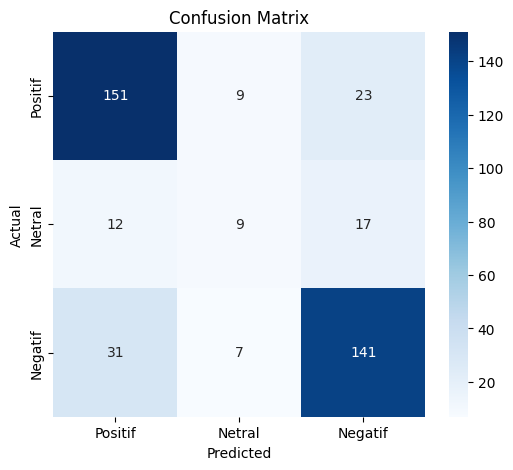

In [ ]:
# ==============================
# EVALUASI MODEL
# ==============================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n" + "="*50)
print("   HASIL AKHIR NAIVE BAYES (OPTIMIZED)")
print("="*50)
print(f"Akurasi   : {acc*100:.2f}%")
print(f"Presisi   : {prec*100:.2f}%")
print(f"Recall    : {rec*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")
print("-" * 50)
print("\nLaporan Klasifikasi Rinci:")
print(classification_report(y_test, y_pred, digits=3))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Positif','Netral','Negatif'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positif','Netral','Negatif'],
            yticklabels=['Positif','Netral','Negatif'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**8. Visualisasi Dan Interpretasi Hasil**

Penyajian dan analisis hasil sentimen untuk menarik kesimpulan penelitian

**WordCloud Keseluruhan Analysis Sentimen Shopee**

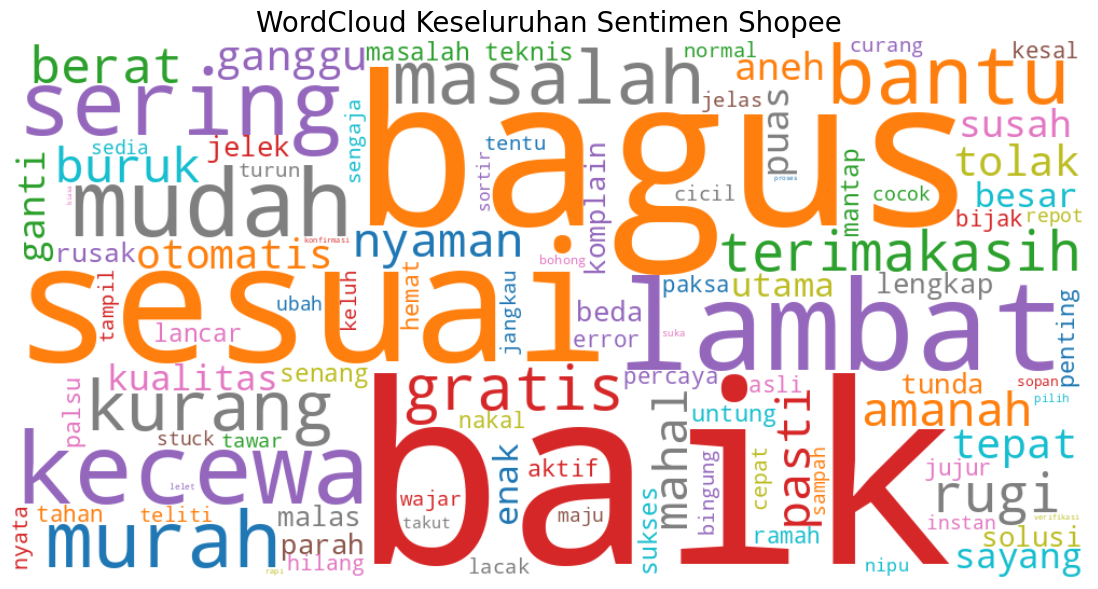

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_sentiment_words = positif_words | netral_words | negatif_words

filtered_words = []

for text in df['stemming'].astype(str):
    for word in text.split():
        if word in all_sentiment_words:
            filtered_words.append(word)

all_text = " ".join(filtered_words)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=200,
    colormap='tab10'
).generate(all_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Keseluruhan Sentimen Shopee", fontsize=20)
plt.show()


**WordCloud Positif Analysis Sentimen Shopee**

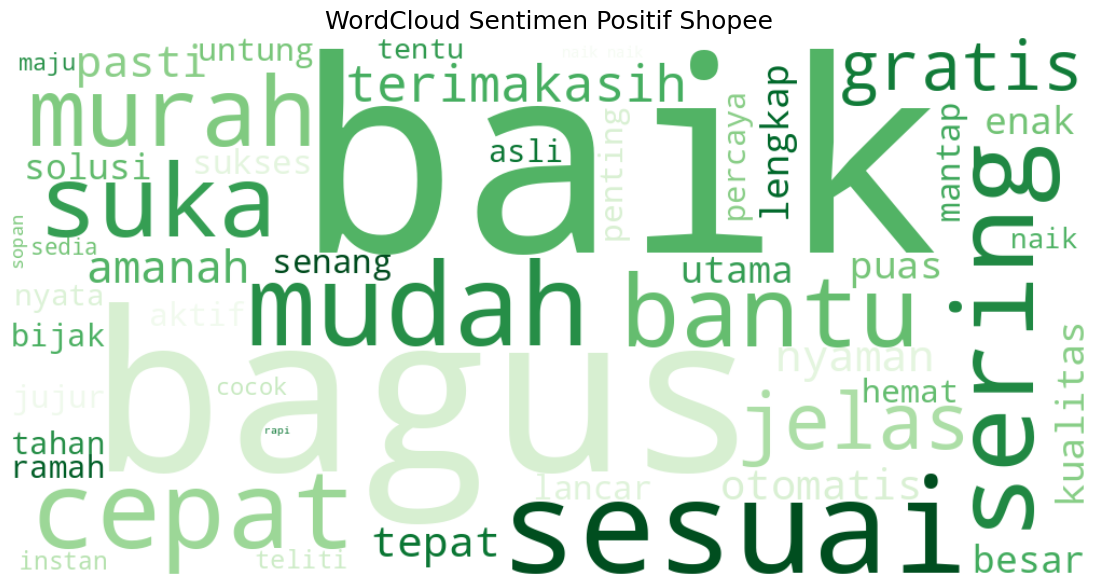

In [ ]:
text_positif = []

for text in df['stemming'].astype(str):
    for word in text.split():
        if word in positif_words:
            text_positif.append(word)

text_positif = " ".join(text_positif)

wc_pos = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='Greens'
).generate(text_positif)

plt.figure(figsize=(15,7))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Sentimen Positif Shopee", fontsize=18)
plt.show()


**WordCloud Netral Analysis Sentimen Shopee**

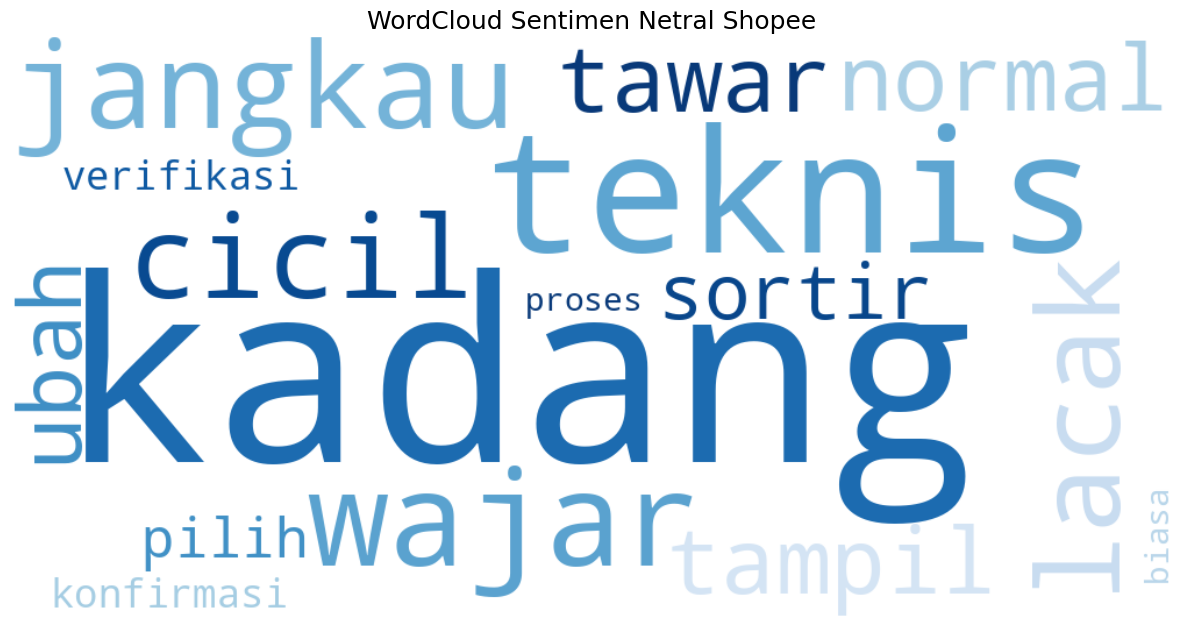

In [ ]:
text_netral = []

for text in df['stemming'].astype(str):
    for word in text.split():
        if word in netral_words:
            text_netral.append(word)

text_netral = " ".join(text_netral)

wc_net = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='Blues'
).generate(text_netral)

plt.figure(figsize=(15,10))
plt.imshow(wc_net, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Sentimen Netral Shopee", fontsize=18)
plt.show()


**WordCloud Negatif Analysis Sentimen Shopee**

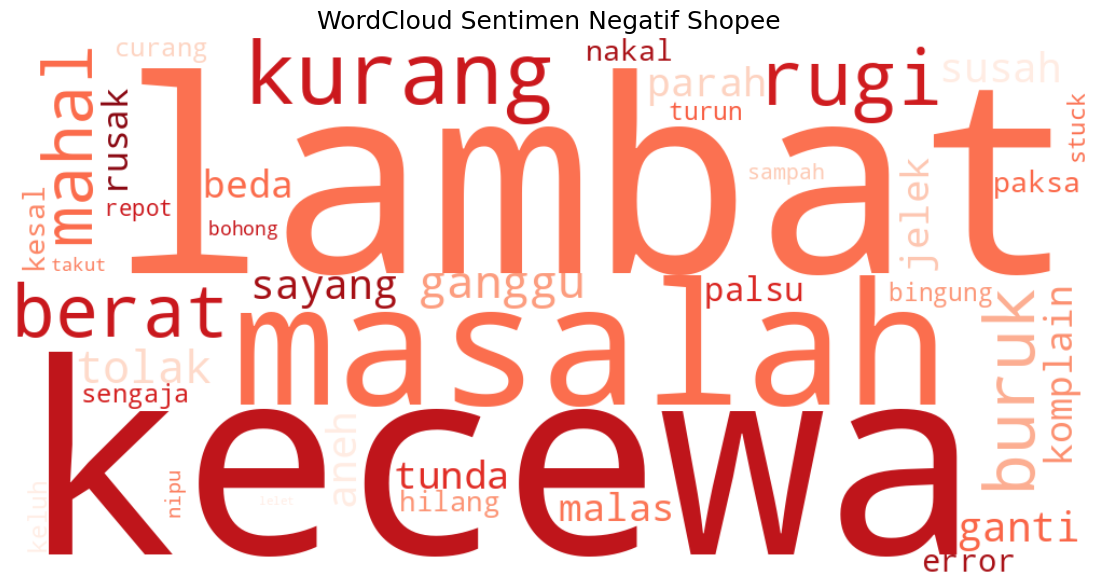

In [ ]:
text_negatif = []

for text in df['stemming'].astype(str):
    for word in text.split():
        if word in negatif_words:
            text_negatif.append(word)

text_negatif = " ".join(text_negatif)

wc_neg = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='Reds'
).generate(text_negatif)

plt.figure(figsize=(15,7))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Sentimen Negatif Shopee", fontsize=18)
plt.show()


**Visualisasi Diagram Batang Distribusi Sentimen Prediksi**



/tmp/ipython-input-3084415609.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


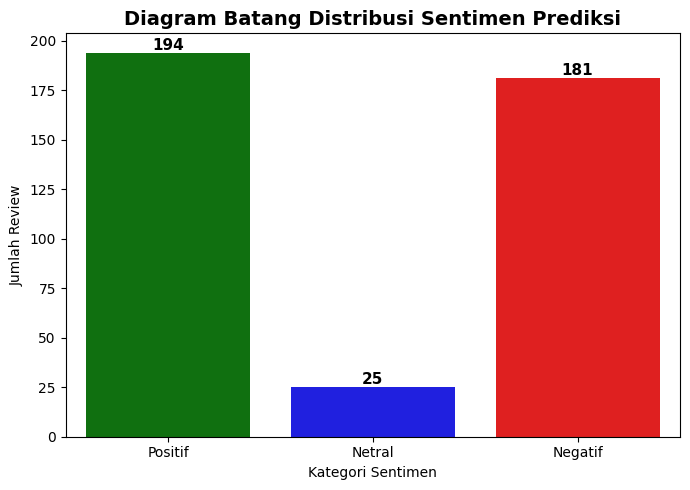

In [ ]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='Predicted',
    data=results,
    order=['Positif', 'Netral', 'Negatif'],
    palette={
        'Positif': 'green',
        'Netral': 'blue',
        'Negatif': 'red'
    }
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Diagram Batang Distribusi Sentimen Prediksi", fontsize=14, fontweight='bold')
plt.xlabel("Kategori Sentimen")
plt.ylabel("Jumlah Review")
plt.tight_layout()
plt.show()

**Visualisasi Diagram Lingkaran Distribusi Sentimen Prediksi**

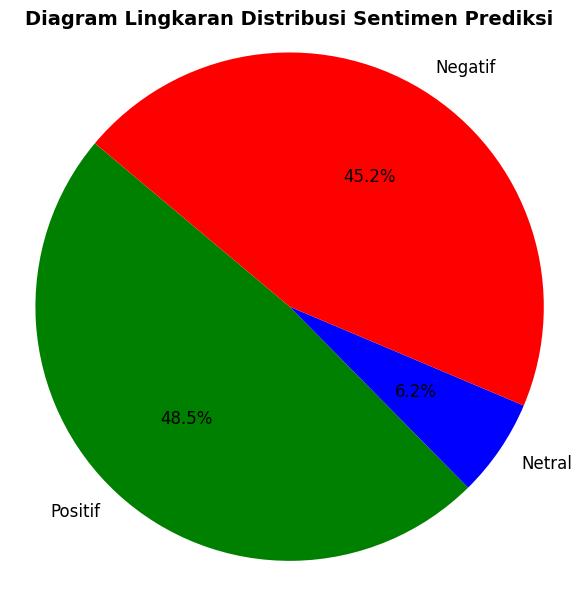

In [ ]:
import matplotlib.pyplot as plt

# Hitung jumlah tiap sentimen
sentiment_counts = results['Predicted'].value_counts().reindex(
    ['Positif', 'Netral', 'Negatif']
)

# Warna konsisten dengan bar chart
colors = ['green', 'blue', 'red']

plt.figure(figsize=(6,6))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',     # tampilkan persentase
    startangle=140,
    colors=colors,
    textprops={'fontsize': 12}
)

plt.title("Diagram Lingkaran Distribusi Sentimen Prediksi", fontsize=14, fontweight='bold')
plt.axis('equal')  # agar lingkaran sempurna
plt.tight_layout()
plt.show()
